# Cycle Time & Idle Detection Analysis

**Purpose:** implement Sections 4.2–4.5 of the paper — DBSCAN stop detection, cycle extraction, phase decomposition, segment classification, and fleet-wide inefficiency quantification (Section D of TASKS.md).

**What this cell does:**

- `import sys, warnings` / `sys.path.append("../..")` — adds the repo root to `sys.path` so `gps_lib` can be imported from `notebooks/analysis/`.
- `warnings.filterwarnings("ignore")` — silences warnings (e.g. pandas `DtypeWarning` on mixed-type CSV columns) so they don't clutter the output.
- `from gps_lib import io_utils, classify, preprocess, zones, stops, cycle_classification, dem, config, plotting` — imports every helper module used in this notebook:
  - `io_utils` — CSV read/write helpers.
  - `classify` — regex-based label classification.
  - `preprocess` — GPS cleaning + motion features.
  - `zones` — zone polygon construction and point-in-zone lookups.
  - `stops` — DBSCAN-based stop/queue detection over low-speed pings.
  - `cycle_classification` — haul-cycle extraction, phase decomposition, and per-ping state classification (transit/operating/queuing/unplanned_idle).
  - `dem` — SRTM digital-elevation-model download/merge/sampling utilities, used for haul-segment grade.
  - `config` — environment configuration (data directory, Navixy API credentials).
  - `plotting` — matplotlib visualizations, including `plot_state_breakdown_by_tracker` used in Section 6.

In [1]:
import sys, warnings
sys.path.append("../..")
warnings.filterwarnings("ignore")

from gps_lib import io_utils, classify, preprocess, zones, stops, cycle_classification, dem, config, plotting

## 1. Load + clean

**What this cell does, line by line:**

1. `io_utils.load_tracker_list()` — reads `tracker_list.csv` (equipment registry).
2. `classify.classify_technic_material_type(...)` — tags each tracker's `technic_m_type` (`bn` if its `label` matches `"BN"`, else `other`). Note: `technic_type` (dump/loader/other), used to filter to dump trucks in cell 3, already exists as a raw column in `tracker_list.csv` — this notebook does not call `classify.classify_technic_type` to derive it.
3. `io_utils.load_gps_data()` — globs and concatenates every `gps_data_<year>-<month>.csv` in `config.DATA_DIR` into one raw-ping DataFrame.
4. `print(...)` — reports the raw row count.
5. `preprocess.attach_technic_info(...)` — inner-joins pings to tracker metadata on `tracker_id == id` (drops pings for unknown trackers).
6. `preprocess.clean_gps_points(..., round_n=4)` — dedupes, parses timestamps, rounds `lat`/`lng` to ~11m precision, and collapses near-duplicate pings (same tracker/hour/location).
7. `print(...)` — reports the row count after cleaning, so you can see how much the join + dedup dropped.

In [2]:
tracker_list_df = io_utils.load_tracker_list()
tracker_list_df = classify.classify_technic_material_type(tracker_list_df)

In [3]:
gps_raw = io_utils.load_gps_data("2025-07")
print(f"Raw GPS rows: {len(gps_raw):,}")

Raw GPS rows: 4,933,618


In [4]:
gps_raw.head()

,address,satellites,mileage,heading,speed,parking,alt,get_time,lat,lng,buffered,tracker_id
0,NaN,15,0.0,6,0,True,1544,2025-07-01 00:00:03,43.664877,105.545123,NaN,18773
1,NaN,16,0.0,6,0,True,1544,2025-07-01 00:00:23,43.664877,105.545123,NaN,18773
2,NaN,14,0.0,6,0,True,1544,2025-07-01 00:00:43,43.664877,105.545123,NaN,18773
3,NaN,15,0.0,6,0,True,1544,2025-07-01 00:01:03,43.664877,105.545123,NaN,18773
4,NaN,15,0.0,6,0,True,1544,2025-07-01 00:01:23,43.664877,105.545123,NaN,18773


In [ ]:
merged = preprocess.attach_technic_info(gps_raw, tracker_list_df)
df = preprocess.clean_gps_points(merged, round_n=4)
print(f"After clean: {len(df):,}")


After clean: 2,421,079


In [27]:
df.describe()

,satellites,mileage,heading,speed,alt,get_time,lat,lng,tracker_id,id,group_id,source_id,source_device_id,source_tariff_id,source_phone,source_status_listing_id,hour,dt,dist,speed_kmh
count,74669.000000,74669.000000,74669.000000,74669.000000,74669.000000,74669,74669.000000,74669.000000,74669.000000,74669.000000,74669.000000,74669.000000,7.466900e+04,74669.0,7.466900e+04,0.0,74669.000000,74631.000000,74631.000000,74631.000000
mean,15.943912,412.376109,176.294152,34.956983,1537.834269,2025-07-02 12:51:27.936466176,43.824167,105.491305,34729.871366,34729.871366,2071.619869,15150.007285,5.507082e+14,1.0,9.768874e+10,NaN,12.372337,36.420616,83.980060,35.769458
min,3.000000,0.000000,0.000000,0.000000,0.000000,2025-07-02 00:00:00,43.588100,104.862500,18773.000000,18773.000000,1509.000000,9216.000000,3.503172e+14,1.0,9.768650e+10,NaN,0.000000,1.000000,0.000000,0.000000
25%,15.000000,188.501000,86.000000,14.000000,1530.000000,2025-07-02 07:48:12,43.656000,105.328400,20507.000000,20507.000000,1511.000000,9902.000000,3.520167e+14,1.0,9.768675e+10,NaN,7.000000,6.000000,26.573207,14.479708
50%,16.000000,379.439000,182.000000,32.000000,1545.000000,2025-07-02 13:31:47,43.664100,105.509900,40224.000000,40224.000000,2571.000000,17242.000000,3.596321e+14,1.0,9.768949e+10,NaN,13.000000,9.000000,100.397799,33.223518
75%,17.000000,607.170000,263.000000,54.000000,1565.000000,2025-07-02 18:26:15,43.681000,105.540100,45503.000000,45503.000000,2571.000000,19001.000000,8.637191e+14,1.0,9.768971e+10,NaN,18.000000,13.000000,132.681680,54.748807
max,22.000000,1048.631000,359.000000,120.000000,1704.000000,2025-07-02 23:59:57,47.924200,106.995600,46078.000000,46078.000000,2571.000000,19200.000000,8.637191e+14,1.0,9.768998e+10,NaN,23.000000,24650.000000,2255.561240,119.970052
std,2.321426,266.047567,100.099634,23.870043,64.532703,NaN,0.706002,0.273231,11214.028006,11214.028006,529.339798,4099.627486,2.477324e+14,0.0,1.353960e+06,NaN,6.719517,248.273310,57.321822,24.065301


In [30]:
import pandas as pd
# df = df[df["date"] == pd.Timestamp("2025-07-02").date()]
df = df[df["technic_m_type"] == "bn"]
df

,address,satellites,mileage,heading,speed,parking,alt,get_time,lat,lng,...,source_creation_date,source_tariff_end_date,technic_type,technic_m_type,date,hour,dt,dist,speed_kmh,implausible_jump
11577,NaN,13,523.461,280,40,NaN,1540,2025-07-02 00:00:01,43.6560,105.5195,...,2021-01-29,2025-11-06,dump,bn,2025-07-02,0,NaN,NaN,NaN,False
11578,NaN,13,523.561,270,47,NaN,1540,2025-07-02 00:00:09,43.6561,105.5182,...,2021-01-29,2025-11-06,dump,bn,2025-07-02,0,8.0,105.173397,47.328028,False
11579,NaN,13,523.671,268,48,NaN,1541,2025-07-02 00:00:17,43.6561,105.5169,...,2021-01-29,2025-11-06,dump,bn,2025-07-02,0,8.0,104.583852,47.062733,False
11580,NaN,14,523.781,264,48,NaN,1543,2025-07-02 00:00:25,43.6560,105.5155,...,2021-01-29,2025-11-06,dump,bn,2025-07-02,0,8.0,113.176422,50.929390,False
11581,NaN,15,523.891,263,50,NaN,1537,2025-07-02 00:00:33,43.6560,105.5142,...,2021-01-29,2025-11-06,dump,bn,2025-07-02,0,8.0,104.584026,47.062812,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74664,NaN,17,924.455,47,10,NaN,1523,2025-07-02 23:46:47,43.6555,105.5090,...,2024-06-03,2025-11-06,dump,bn,2025-07-02,23,8.0,13.724617,6.176078,False
74665,NaN,17,924.465,65,13,NaN,1525,2025-07-02 23:46:52,43.6556,105.5091,...,2024-06-03,2025-11-06,dump,bn,2025-07-02,23,5.0,13.724610,9.881719,False
74666,NaN,15,924.485,84,12,NaN,1525,2025-07-02 23:46:56,43.6556,105.5093,...,2024-06-03,2025-11-06,dump,bn,2025-07-02,23,4.0,16.089957,14.480962,False
74667,NaN,17,924.505,100,8,NaN,1529,2025-07-02 23:47:05,43.6556,105.5096,...,2024-06-03,2025-11-06,dump,bn,2025-07-02,23,9.0,24.134936,9.653974,False


In [7]:
df["technic_m_type"].unique()

array(['other', 'bn'], dtype=object)

## 2. Motion features + implausible-jump removal

**What this cell does:**

1. `preprocess.add_motion_features(df)` — sorts by `tracker_id, get_time` and computes `dt` (sec since previous ping), `dist` (haversine meters), `speed_kmh`, and `implausible_jump` (`speed_kmh > 120` by default) per tracker.
2. `n_jump = int(df["implausible_jump"].sum())` — counts flagged pings.
3. `print(...)` — reports the count and percentage of implausible pings, and states they're being dropped (unlike `data_qa.ipynb`, which only flags them for inspection).
4. `df = df[~df["implausible_jump"]].reset_index(drop=True)` — actually removes those pings from `df`, since downstream cycle/DBSCAN analysis needs clean trajectories.
5. `df["speed_kmh"].describe(percentiles=[.5,.9,.99])` — summary stats of implied speed after the implausible pings are removed, at the median/90th/99th percentiles.

In [31]:
df = preprocess.add_motion_features(df)
n_jump = int(df["implausible_jump"].sum())
print(f"Implausible pings: {n_jump:,} ({n_jump/len(df):.3%}) — dropping")
df = df[~df["implausible_jump"]].reset_index(drop=True)
df["speed_kmh"].describe(percentiles=[.5,.9,.99])

Implausible pings: 0 (0.000%) — dropping


count    36920.000000
mean        40.429104
std         19.038558
min          0.000000
50%         46.354446
90%         60.817429
99%         68.272525
max        117.563324
Name: speed_kmh, dtype: float64

In [9]:
df.head()

,address,satellites,mileage,heading,speed,parking,alt,get_time,lat,lng,...,source_creation_date,source_tariff_end_date,technic_type,technic_m_type,date,hour,dt,dist,speed_kmh,implausible_jump
0,NaN,7,27.66,0,0,True,1551,2025-07-02 03:21:40,43.6685,105.5449,...,2020-08-13,2025-11-06,dump,other,2025-07-02,3,NaN,NaN,NaN,False
1,NaN,13,27.66,0,0,True,1539,2025-07-02 03:22:00,43.6686,105.5450,...,2020-08-13,2025-11-06,dump,other,2025-07-02,3,20.0,13.723589,2.470246,False
2,NaN,7,27.66,192,17,NaN,1500,2025-07-02 03:37:58,43.6681,105.5448,...,2020-08-13,2025-11-06,dump,other,2025-07-02,3,958.0,57.877929,0.217495,False
3,NaN,14,27.68,190,6,NaN,1445,2025-07-02 03:38:00,43.6680,105.5451,...,2020-08-13,2025-11-06,dump,other,2025-07-02,3,2.0,26.568717,47.823690,False
4,"Transgobi road, Цогтцэций, Өмнөговь",19,27.68,172,0,NaN,1451,2025-07-02 03:38:20,43.6683,105.5452,...,2020-08-13,2025-11-06,dump,other,2025-07-02,3,20.0,34.314468,6.176604,False


## 3. Dump trucks only

**What this cell does:**

`dumps = df[df["technic_type"] == "dump"].copy()` — filters to only dump-truck pings, using the `technic_type` column that comes straight from `tracker_list.csv`. All downstream cycle/zone/DBSCAN analysis in this notebook only concerns dump trucks, since a haul cycle (load → haul → dump → return) is a dump-truck-specific concept. `print(...)` reports how many pings and how many distinct dump trackers remain.

In [32]:
dumps = df[df["technic_type"] == "dump"].copy()
print(f"Dump pings: {len(dumps):,}  |  Dump trackers: {dumps['tracker_id'].nunique()}")

Dump pings: 36,933  |  Dump trackers: 13


## 4. Load zone geometry + DBSCAN eps sizing

**What this cell does:**

1. `io_utils.load_zone_list()` + `classify.classify_zones(..., drop_other=True)` — loads zone metadata and tags each zone's material type (reject/bn/middling/other) and load type (load/unload), dropping zones whose material type is `other`.
2. `io_utils.load_zone_detail()` — loads the raw polygon vertex list per zone.
3. `zones.build_zone_geodataframe(...)` — builds a shapely/geopandas polygon per zone with that metadata attached.
4. `zones.zone_diameter_stats(zones_gdf)` — computes each zone's bounding-box diagonal in meters, sorted ascending.
5. `diam["diameter_m"].describe(...).round(1)` — prints summary statistics of zone sizes across the mine, rounded to 1 decimal, to inform the DBSCAN `eps` choice made in the next cell.

In [33]:
zone_list_df = io_utils.load_zone_list()
zone_list_df = classify.classify_zones(zone_list_df, drop_other=True)
zone_detail_df = io_utils.load_zone_detail()
zones_gdf = zones.build_zone_geodataframe(zone_detail_df, zone_list_df)

diam = zones.zone_diameter_stats(zones_gdf)
diam["diameter_m"].describe(percentiles=[.1,.25,.5,.75,.9]).round(1)

count      11.0
mean      792.1
std       814.7
min       284.9
10%       292.0
25%       306.4
50%       428.9
75%       896.8
90%      1455.7
max      2969.4
Name: diameter_m, dtype: float64

**What this cell does:**

- `rec_eps = round(diam["diameter_m"].quantile(0.10) / 2, 1)` — takes the 10th-percentile (small) zone diameter and halves it, giving a DBSCAN `eps` (cluster radius, meters) that should stay within a single small zone's footprint rather than merging adjacent zones into one stop-cluster. This value (`rec_eps`) is reused later for the actual stop clustering.
- The two `print(...)` calls report the recommended `eps` and a fixed `min_samples` of 3, justified as roughly a 60-second minimum dwell time divided by a ~20-second GPS ping interval — i.e. the number of pings you'd expect during the shortest plausible real stop.

In [34]:
rec_eps = round(diam["diameter_m"].quantile(0.10) / 2, 1)
print(f"Recommended eps: {rec_eps} m")
print(f"Recommended min_samples: 3  (~60s dwell / 20s ping interval)")

Recommended eps: 146.0 m
Recommended min_samples: 3  (~60s dwell / 20s ping interval)


## 5. Assign zone hits to all dump pings

**What this cell does:**

1. `zones.assign_zone_hit(dumps, zones_gdf)` — spatial-joins every dump-truck ping against the zone polygons (via `geopandas.sjoin`, `predicate="within"`) to find which zone (if any) each ping falls inside, adding `zone_id_hit`, `zone_mat_hit`, `zone_load_hit` columns.
2. `n_inside = gps_hits["zone_id_hit"].notna().sum()` / `print(...)` — reports how many pings fall inside any known zone polygon, and what fraction of all dump pings that is.
3. `gps_hits[[...]].head(10)` — previews 10 pings with their tracker, time, location, raw `speed`, and the zone material/load type each was matched to.

In [35]:
gps_hits = zones.assign_zone_hit(dumps, zones_gdf)
n_inside = gps_hits["zone_id_hit"].notna().sum()
print(f"Pings inside a zone: {n_inside:,} ({n_inside/len(gps_hits):.1%})")


Pings inside a zone: 1,656 (4.5%)


In [36]:
gps_hits[["tracker_id","get_time","lat","lng","speed","zone_mat_hit","zone_load_hit"]].head(20)

,tracker_id,get_time,lat,lng,speed,zone_mat_hit,zone_load_hit
0,20505,2025-07-02 00:00:01,43.6560,105.5195,40,NaN,NaN
1,20505,2025-07-02 00:00:09,43.6561,105.5182,47,NaN,NaN
2,20505,2025-07-02 00:00:17,43.6561,105.5169,48,NaN,NaN
3,20505,2025-07-02 00:00:25,43.6560,105.5155,48,NaN,NaN
4,20505,2025-07-02 00:00:33,43.6560,105.5142,50,NaN,NaN
5,20505,2025-07-02 00:00:41,43.6559,105.5129,38,NaN,NaN
6,20505,2025-07-02 00:00:48,43.6557,105.5121,26,NaN,NaN
7,20505,2025-07-02 00:00:56,43.6555,105.5116,16,NaN,NaN
8,20505,2025-07-02 00:01:05,43.6555,105.5113,6,NaN,NaN
9,20505,2025-07-02 00:01:25,43.6556,105.5111,0,NaN,NaN


## 6. Segment classification (transit / operating / queuing / unplanned_idle)

**What this cell does:**

1. `cycle_classification.classify_segments(gps_hits, zones_gdf, speed_threshold=2.0, queue_buffer_m=50.0)` — tags every ping's `state`:
   - `operating`: stopped (`speed < 2.0`) and inside a zone polygon.
   - `queuing`: stopped, outside any zone, but within 50m of a load-zone polygon (waiting for the shovel) — computed by buffering load-zone geometry by `queue_buffer_m / 111320` degrees (~50m) and re-testing.
   - `unplanned_idle`: stopped, outside all zones, and not near a load zone.
   - `transit`: everything else (moving).
2. `cycle_classification.state_time_breakdown(classified, dt_col="dt")` — sums `dt` (seconds since previous ping) per state and divides by total time, giving the fleet-wide time fraction spent in each state — a `dt`-weighted breakdown rather than a simple ping-count breakdown. The loop prints each state and its percentage share of total fleet time.
3. `N_TRUCKS = 3` — how many trucks to chart/map below; set it to any int, or the string `"all"` to include every dump truck.
4. `tracker_labels = tracker_list_df.set_index("id")["label"].to_dict()` — a `{tracker_id: label}` lookup used so both the chart and maps show readable truck labels instead of raw ids.
5. `cycle_classification.state_time_breakdown_by_tracker(classified, dt_col="dt")` — the per-truck version of step 2: for each `tracker_id`, the `dt`-weighted fraction of *that truck's own* tracked time spent in each state (rows sum to 1.0, so trucks with less data aren't penalized relative to busier ones).
6. `plotting.plot_state_breakdown_by_tracker(...)` — draws a stacked horizontal bar chart, one bar per truck (first `N_TRUCKS`, or all of them), each segment colored by state using a fixed color assignment (`plotting.STATE_COLOR_MAP`, where `unplanned_idle` is red) so a state's color never changes based on which/how many trucks are shown. Segments ≥4% get a direct `%` label; a legend below the chart identifies the four states.
7. `selected_trackers = breakdown_by_tracker.head(N_TRUCKS).index ...` — reuses the exact same set of trucks the bar chart just showed, so the chart and maps stay in sync.
8. `plotting.plot_state_map_grid(classified, zones_gdf, tracker_ids=selected_trackers, label_map=tracker_labels)` — the spatial counterpart: one small map subplot **per truck** (rather than all trucks overlaid on a single map), each showing that truck's raw GPS pings (lat/lng) colored by `state` with the same fixed `STATE_COLOR_MAP`, drawn over the zone polygons (lightly shaded by `zone_material_type`) for geographic context, with a shared legend below the grid — so you can compare where each truck transits/operates/queues/idles side by side.


Fleet-wide state-time breakdown (dt-weighted):
  transit               50.4%
  unplanned_idle        47.7%
  operating             1.9%


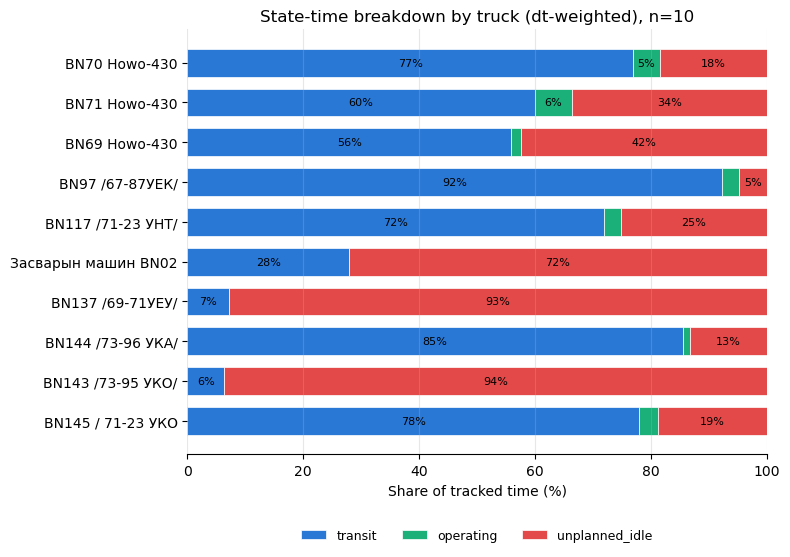

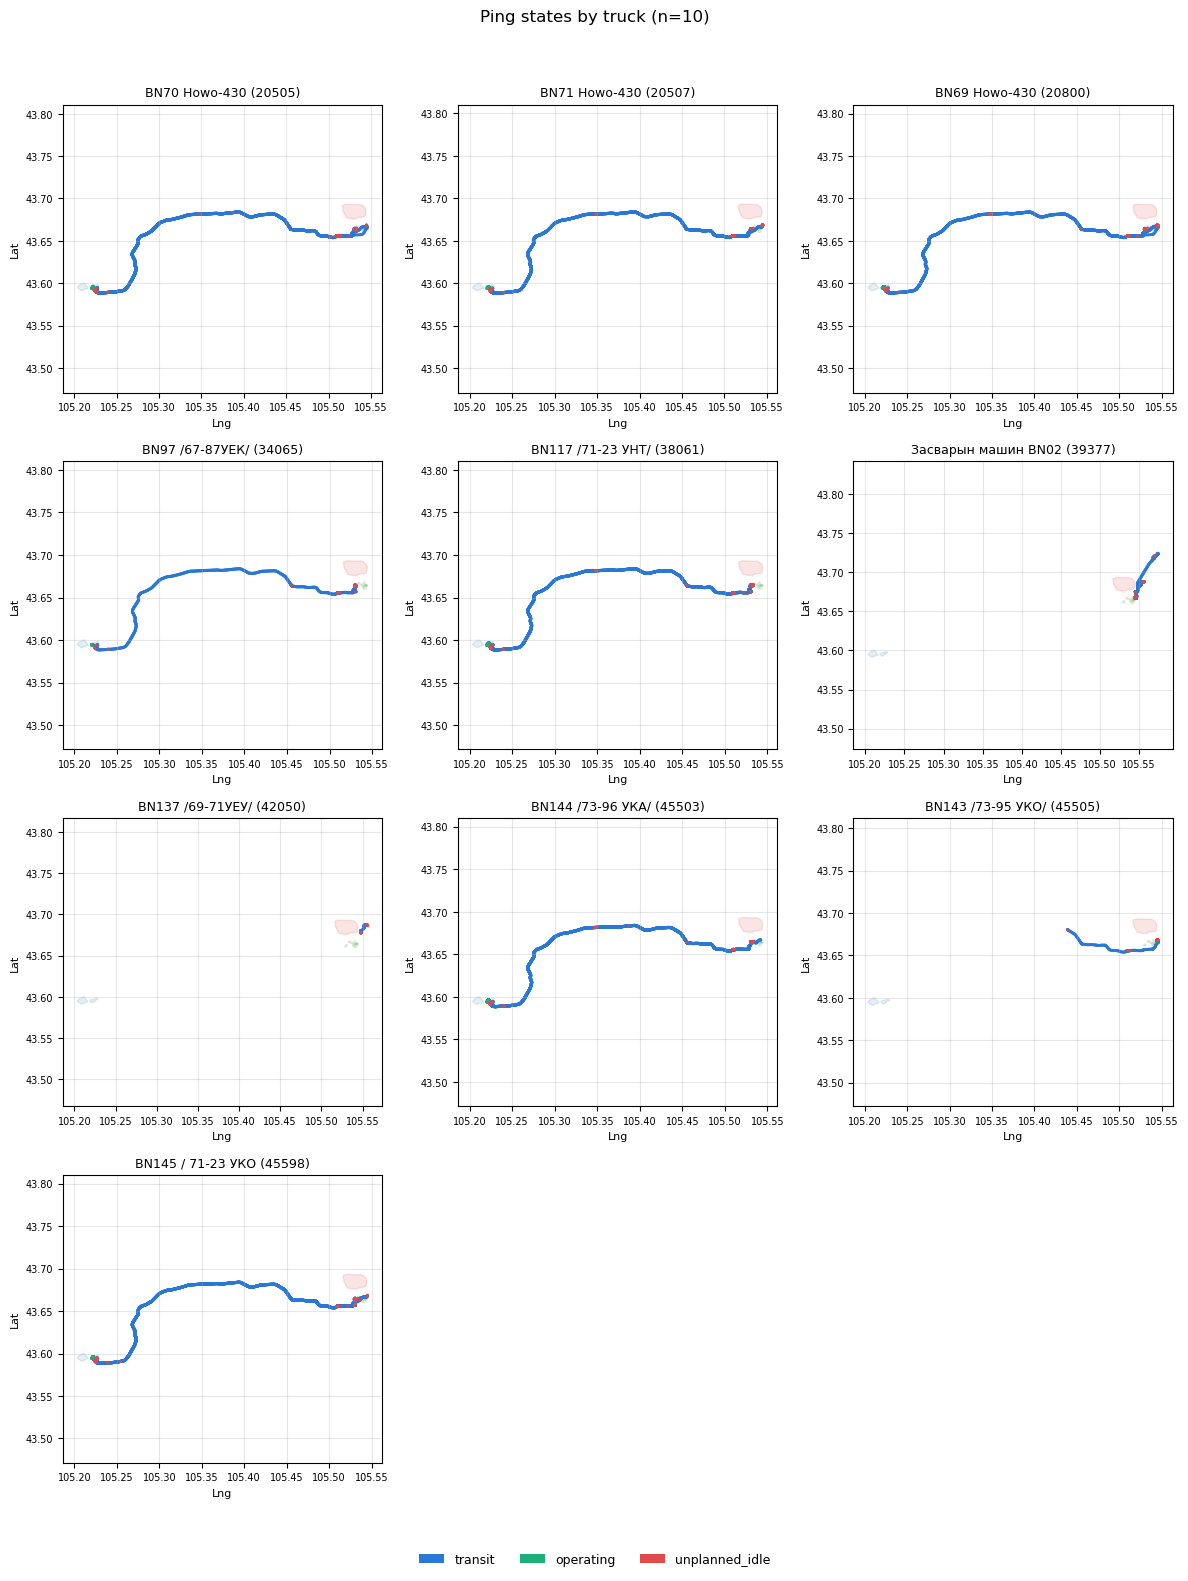

(<Figure size 1200x1600 with 12 Axes>,
 array([[<Axes: title={'center': 'BN70 Howo-430 (20505)'}, xlabel='Lng', ylabel='Lat'>,
         <Axes: title={'center': 'BN71 Howo-430 (20507)'}, xlabel='Lng', ylabel='Lat'>,
         <Axes: title={'center': 'BN69 Howo-430 (20800)'}, xlabel='Lng', ylabel='Lat'>],
        [<Axes: title={'center': 'BN97 /67-87УЕК/ (34065)'}, xlabel='Lng', ylabel='Lat'>,
         <Axes: title={'center': 'BN117 /71-23 УНТ/ (38061)'}, xlabel='Lng', ylabel='Lat'>,
         <Axes: title={'center': 'Засварын машин BN02 (39377)'}, xlabel='Lng', ylabel='Lat'>],
        [<Axes: title={'center': 'BN137 /69-71УЕУ/ (42050)'}, xlabel='Lng', ylabel='Lat'>,
         <Axes: title={'center': 'BN144 /73-96 УКА/ (45503)'}, xlabel='Lng', ylabel='Lat'>,
         <Axes: title={'center': 'BN143 /73-95 УКО/ (45505)'}, xlabel='Lng', ylabel='Lat'>],
        [<Axes: title={'center': 'BN145 / 71-23 УКО (45598)'}, xlabel='Lng', ylabel='Lat'>,
         <Axes: >, <Axes: >]], dtype=object))

In [37]:
classified = cycle_classification.classify_segments(gps_hits, zones_gdf, speed_threshold=2.0, queue_buffer_m=50.0)
breakdown = cycle_classification.state_time_breakdown(classified, dt_col="dt")
print("\nFleet-wide state-time breakdown (dt-weighted):")
for state, frac in breakdown.items():
    print(f"  {state:<20s}  {frac:.1%}")

# Per-truck breakdown, visualized as a stacked bar chart + one map per truck.
# N_TRUCKS: an int (first N trucks) or "all" to show every dump truck.
N_TRUCKS = 10
tracker_labels = tracker_list_df.set_index("id")["label"].to_dict()
breakdown_by_tracker = cycle_classification.state_time_breakdown_by_tracker(classified, dt_col="dt")
plotting.plot_state_breakdown_by_tracker(breakdown_by_tracker, n_trackers=N_TRUCKS, label_map=tracker_labels)

selected_trackers = breakdown_by_tracker.head(N_TRUCKS).index if N_TRUCKS != "all" else breakdown_by_tracker.index
plotting.plot_state_map_grid(classified, zones_gdf, tracker_ids=selected_trackers, label_map=tracker_labels)

**What this cell does:**

1. `classified.head()` / `breakdown.head()` — quick previews of the per-ping classified table and the fleet-wide breakdown Series computed above.
2. `plotting.plot_state_map_grid(classified, zones_gdf, n_trackers="all", label_map=tracker_labels)` — one small map subplot per dump truck (all of them, not just the `N_TRUCKS` subset from the chart above), each truck's pings plotted by `lat`/`lng` and colored by `state` (`unplanned_idle` in red), over the zone polygons for context. This is the full-fleet counterpart to the 3-truck grid plotted earlier — useful for scanning every truck's spatial pattern at once (e.g. spotting which specific trucks have red `unplanned_idle` clusters, and where).

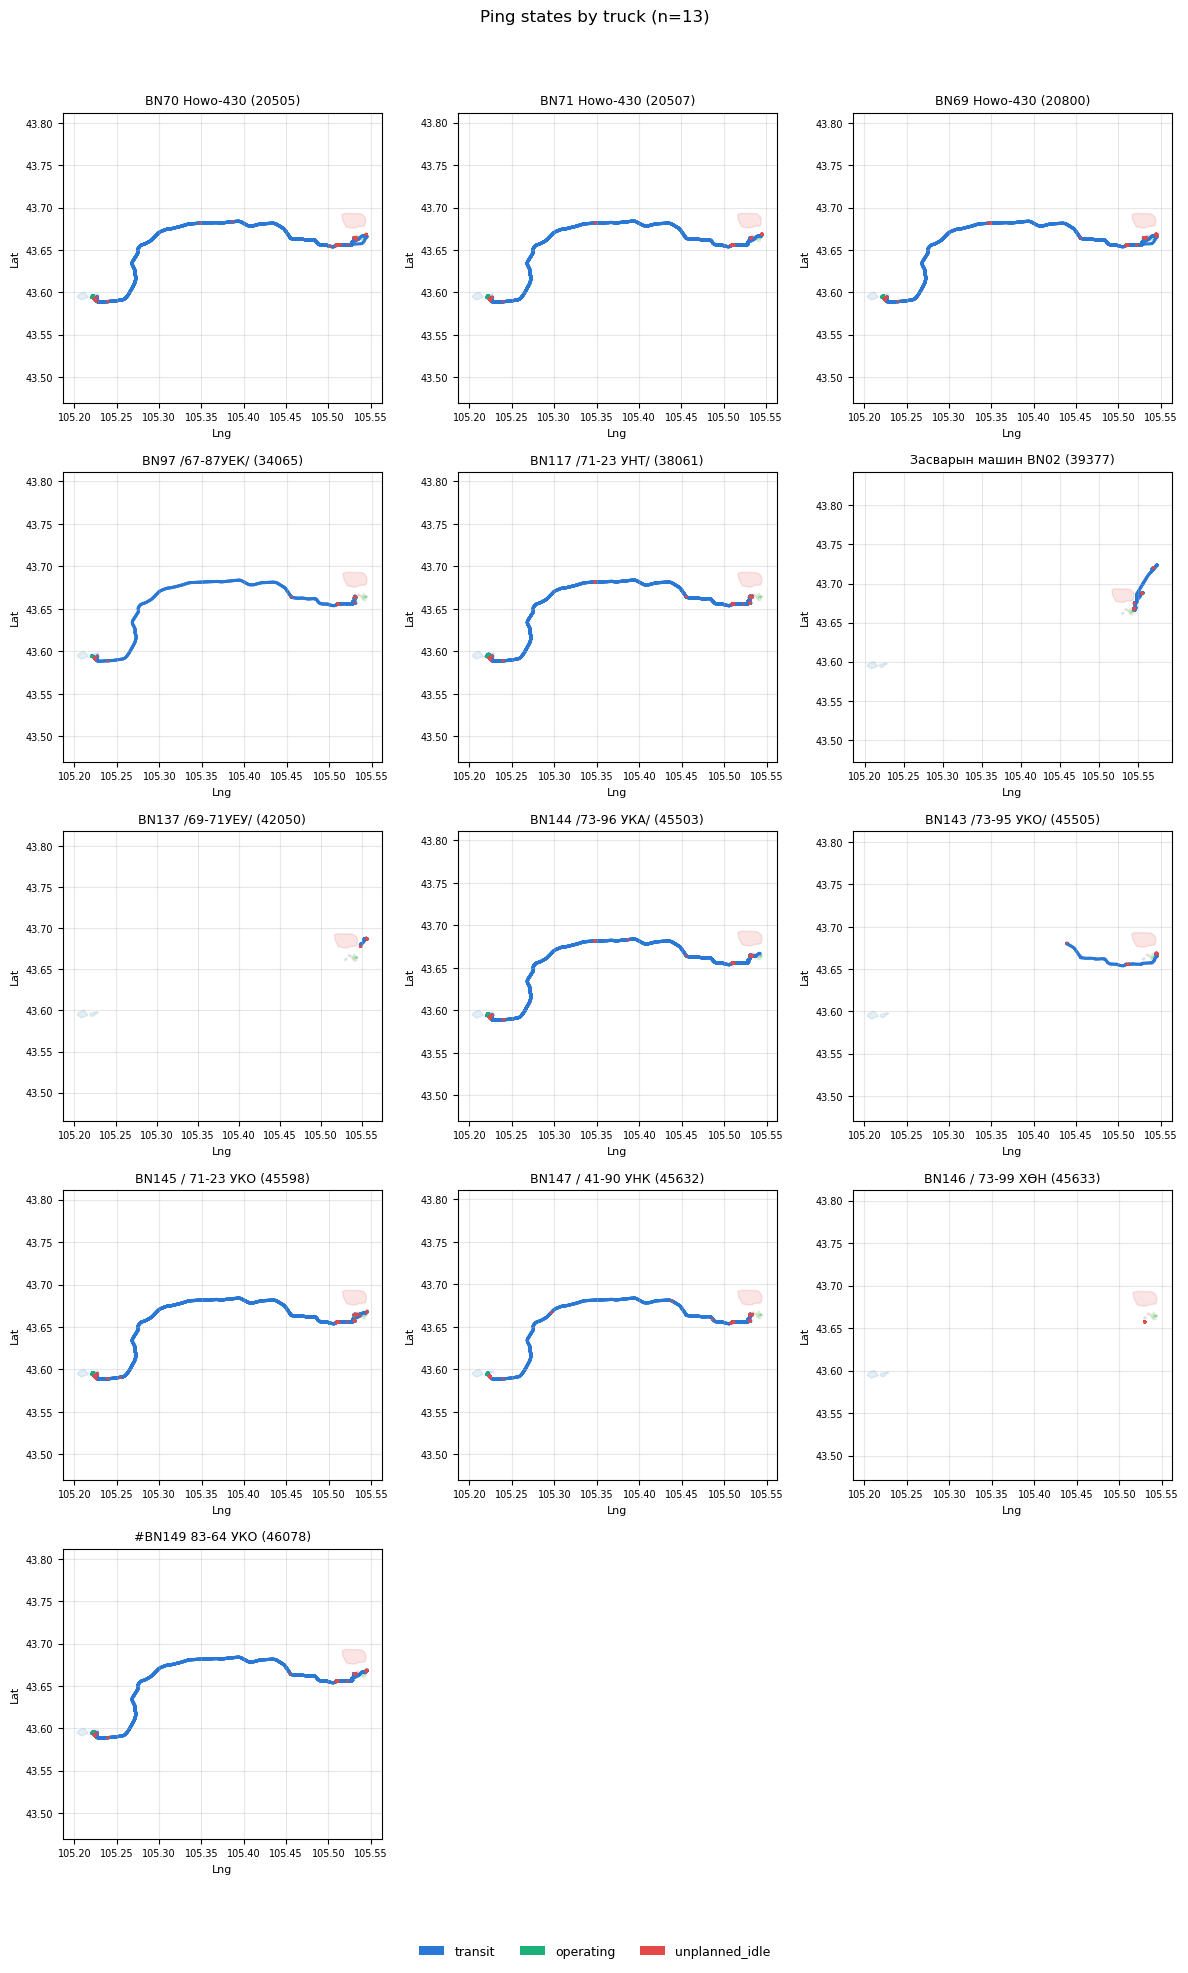

(<Figure size 1200x2000 with 15 Axes>,
 array([[<Axes: title={'center': 'BN70 Howo-430 (20505)'}, xlabel='Lng', ylabel='Lat'>,
         <Axes: title={'center': 'BN71 Howo-430 (20507)'}, xlabel='Lng', ylabel='Lat'>,
         <Axes: title={'center': 'BN69 Howo-430 (20800)'}, xlabel='Lng', ylabel='Lat'>],
        [<Axes: title={'center': 'BN97 /67-87УЕК/ (34065)'}, xlabel='Lng', ylabel='Lat'>,
         <Axes: title={'center': 'BN117 /71-23 УНТ/ (38061)'}, xlabel='Lng', ylabel='Lat'>,
         <Axes: title={'center': 'Засварын машин BN02 (39377)'}, xlabel='Lng', ylabel='Lat'>],
        [<Axes: title={'center': 'BN137 /69-71УЕУ/ (42050)'}, xlabel='Lng', ylabel='Lat'>,
         <Axes: title={'center': 'BN144 /73-96 УКА/ (45503)'}, xlabel='Lng', ylabel='Lat'>,
         <Axes: title={'center': 'BN143 /73-95 УКО/ (45505)'}, xlabel='Lng', ylabel='Lat'>],
        [<Axes: title={'center': 'BN145 / 71-23 УКО (45598)'}, xlabel='Lng', ylabel='Lat'>,
         <Axes: title={'center': 'BN147 / 41-90 УНК

In [38]:
classified.head()
breakdown.head()

plotting.plot_state_map_grid(classified, zones_gdf, n_trackers="all", label_map=tracker_labels)

**What this cell does:**

1. `classified["month"] = pd.to_datetime(classified["get_time"]).dt.to_period("M")` — buckets each ping into its calendar month.
2. Filters to pings with a valid, positive `dt`, groups by `(month, state)`, and sums `dt` — `.unstack(fill_value=0)` pivots `state` into columns, giving total seconds per state per month.
3. `(monthly.div(monthly.sum(axis=1), axis=0) * 100).round(1)` — normalizes each month's row to percentages (state-time as % of that month's total tracked time), showing whether transit/operating/queuing/unplanned_idle shares are trending up or down over time.

In [39]:
# Monthly trend
import pandas as pd
classified["month"] = pd.to_datetime(classified["get_time"]).dt.to_period("M")
monthly = (
    classified[classified["dt"].notna() & (classified["dt"] > 0)]
    .groupby(["month","state"])["dt"].sum().unstack(fill_value=0)
)
(monthly.div(monthly.sum(axis=1), axis=0) * 100).round(1)

state,operating,transit,unplanned_idle
month,,,
2025-07,1.9,50.4,47.7


## 7. Cycle extraction + phase decomposition

**What this cell does, line by line:**

1. `cycle_classification.extract_cycles(gps_hits, load_value="load")` — for each dump tracker, finds every consecutive run of pings where `zone_load_hit == "load"` (a load-zone visit), takes each visit's first ping as a cycle boundary ("arrival"), and slices the trajectory between consecutive arrivals into one cycle each (load visit → haul → dump → haul back → next load visit).
2. `cycle_classification.cycles_to_dataframe(cyc_list)` — flattens the list of cycles into one summary row per cycle, adding phase durations via `decompose_cycle`.
3. `cyc_df["load_zone_mat"] = [c["points"].iloc[0]["zone_mat_hit"] for c in cyc_list]` — tags each cycle with the material type (`bn` / `middling` / `reject` / ...) of the load zone it started in, by reading `zone_mat_hit` off the cycle's first ping (its load-zone arrival). This relies on `cyc_df` and `cyc_list` staying in the same order — `cycles_to_dataframe` builds rows by iterating `cyc_list` via `enumerate`, so row `i` of `cyc_df` always corresponds to `cyc_list[i]`.
4. The three `print(...)` calls report: total cycles extracted, how many included at least one dump-zone visit ("complete" cycles), and how many were missing one.
5. `cyc_df.groupby("load_zone_mat").agg(...)` — breaks the same total/with-dump counts down per load-zone material type, so you can see e.g. whether `bn` cycles are more or less likely to be missing a dump visit than `middling` cycles.

In [40]:
cyc_list = cycle_classification.extract_cycles(gps_hits, load_value="load")
cyc_df = cycle_classification.cycles_to_dataframe(cyc_list)
cyc_df["load_zone_mat"] = [c["points"].iloc[0]["zone_mat_hit"] for c in cyc_list]

print(f"Total cycles: {len(cyc_df):,}")
print(f"With dump visit: {cyc_df['n_dump_visits'].gt(0).sum():,}")
print(f"Missing dump:    {cyc_df['n_dump_visits'].eq(0).sum():,}")

print("\nCycles by load-zone material type:")
print(
    cyc_df.groupby("load_zone_mat").agg(
        n_cycles=("cycle_idx", "count"),
        with_dump=("n_dump_visits", lambda x: (x > 0).sum()),
    )
)

Total cycles: 56
With dump visit: 47
Missing dump:    9

Cycles by load-zone material type:
               n_cycles  with_dump
load_zone_mat                     
bn                   46         43
middling             10          4


**What this cell does:**

1. `complete = cyc_df[cyc_df["n_dump_visits"] > 0].copy()` — restricts to cycles that had at least one detected dump-zone visit (i.e. cycles where all four phases could be computed).
2. The loop converts each `..._sec` phase-duration column (`load_dwell_sec`, `haul_to_dump_sec`, `dump_dwell_sec`, `haul_to_load_sec`, `total_sec`) into minutes as a new `..._min` column.
3. `complete.groupby("load_zone_mat")[min_cols].describe(percentiles=[.25,.5,.75]).round(1)` — instead of one fleet-wide summary, groups by `load_zone_mat` (bn / middling / reject / ...) first, so each material type gets its own count/mean/std/quartile breakdown of load-dwell, haul, and dump-dwell minutes — letting you compare cycle-phase durations across load-zone material types.

In [41]:
# Phase durations in minutes, broken down by load-zone material type
complete = cyc_df[cyc_df["n_dump_visits"] > 0].copy()
for col in ["load_dwell_sec","haul_to_dump_sec","dump_dwell_sec","haul_to_load_sec","total_sec"]:
    complete[col.replace("sec","min")] = complete[col] / 60

min_cols = [c for c in complete.columns if c.endswith("_min")]
complete.groupby("load_zone_mat")[min_cols].describe(percentiles=[.25,.5,.75]).round(1)

load_dwell_min                                           \
                       count  mean   std  min   25%   50%   75%   max   
load_zone_mat                                                           
bn                      43.0  20.3  10.8  7.8  14.0  17.0  23.0  64.1   
middling                 4.0   0.4   0.1  0.3   0.3   0.3   0.4   0.6   

              haul_to_dump_min        ... haul_to_load_min        total_min  \
                         count  mean  ...              75%    max     count   
load_zone_mat                         ...                                     
bn                        43.0  70.8  ...            119.3  941.6      43.0   
middling                   4.0   0.7  ...             14.3   54.9       4.0   

                                                                
                mean    std   min    25%    50%    75%     max  
load_zone_mat                                                   
bn             206.8  142.1  88.7  148.5  180.0  224.5  1031.4  
middling       245.6  201.5  25.8  105.0  247.7  388.3   461.2  

[2 rows x 40 columns]

## 8. DBSCAN stop clustering + unplanned-idle share

**What this cell does:**

1. `stops.filter_stop_pings(gps_hits, speed_threshold=2.0)` — keeps only pings where `speed < 2.0` (stationary).
2. `print(...)` — reports the stop-ping count and its share of all dump pings.
3. `stops.cluster_and_label_stops(stop_df, zones_gdf, eps_m=rec_eps, min_samples=3)` — runs DBSCAN (haversine metric, via `clustering.dbscan_cluster_stops`) over the stop pings' lat/lng using the `rec_eps` computed earlier, assigns each ping a `stop_cluster` id (`-1` = noise, not part of any dense stop), then labels each cluster by matching its centroid against zone polygons — clusters whose centroid isn't inside any known zone are labeled `"unplanned"`.
4. Computes and prints: `n_clustered` (pings in some real cluster), how many of those are inside a known zone vs. `"unplanned"`, and `stops.unplanned_idle_share(...)` — the fraction of all clustered (non-noise) stop pings that are unplanned, i.e. stopping somewhere with no surveyed zone.

In [45]:
stop_df = stops.filter_stop_pings(gps_hits, speed_threshold=2.0)
print(f"Stop pings: {len(stop_df):,} ({len(stop_df)/len(gps_hits):.1%})")

labeled_stops = stops.cluster_and_label_stops(stop_df, zones_gdf, eps_m=rec_eps, min_samples=3)
n_clustered = (labeled_stops["stop_cluster"] != -1).sum()
n_unplanned = (labeled_stops["zone_mat_hit"] == "unplanned").sum()
print(f"Clustered: {n_clustered:,}  |  In-zone: {n_clustered - n_unplanned:,}  |  Unplanned idle: {n_unplanned:,}")
print(f"Unplanned idle share: {stops.unplanned_idle_share(labeled_stops):.1%}")

Stop pings: 1,137 (3.1%)
Clustered: 1,121  |  In-zone: 1,121  |  Unplanned idle: 0
Unplanned idle share: 0.0%


`plotting.plot_dbscan_stop_clusters(labeled_stops, zones_gdf)` — plots every DBSCAN cluster found above, directly on the map, over the zone polygons. Noise pings (`stop_cluster == -1`) are shown as muted gray dots; every real cluster gets its own color (cycling through a qualitative colormap, since cluster count is algorithm-determined, not a fixed set of named categories); each cluster's centroid is ringed and numbered — black ring if that cluster's centroid matched a known zone, red if it didn't (a candidate missing zone, same convention as `plot_candidate_zones`). This is the direct visual of what Section 9a quantifies: whether the dense, recurring stop locations DBSCAN found actually line up with the mine's surveyed zones.

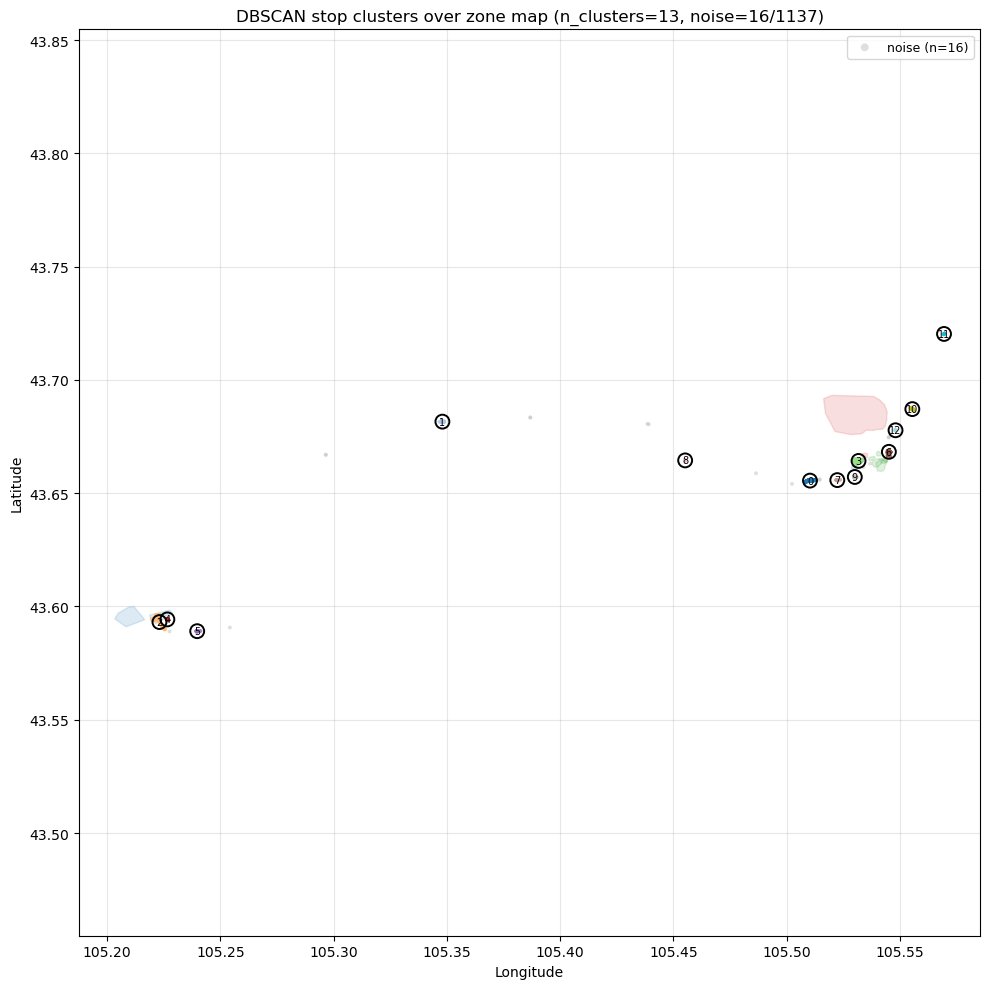

(<Figure size 1000x1000 with 1 Axes>,
 <Axes: title={'center': 'DBSCAN stop clusters over zone map (n_clusters=13, noise=16/1137)'}, xlabel='Longitude', ylabel='Latitude'>)

In [43]:
plotting.plot_dbscan_stop_clusters(labeled_stops, zones_gdf)

## 9. DBSCAN sensitivity sweep

**What this cell does:**

`stops.dbscan_sensitivity_sweep(stop_df, zones_gdf, eps_values=[20, rec_eps, 60, 100], min_samples_values=[2, 3, 5])` — re-runs `cluster_and_label_stops` across every combination of the given `eps` (meters) and `min_samples` values (4 × 3 = 12 runs), and for each combination reports the number of clusters found, the number/share of noise pings, and the unplanned-idle share. Displaying `sweep` shows how sensitive the stop-detection and unplanned-idle metrics are to the DBSCAN parameter choice — the robustness check called for in Section 4.6 / TASKS.md Section C, letting you confirm `rec_eps`/`min_samples=3` isn't a fragile pick.

In [44]:
sweep = stops.dbscan_sensitivity_sweep(
    stop_df, zones_gdf,
    eps_values=[20, rec_eps, 60, 100],
    min_samples_values=[2, 3, 5],
)
sweep

,eps_m,min_samples,n_clusters,n_noise_pings,noise_share,unplanned_idle_share
0,20.0,2,40,29,0.025506,0.0
1,20.0,3,28,53,0.046614,0.0
2,20.0,5,21,97,0.085312,0.0
3,146.0,2,18,6,0.005277,0.0
4,146.0,3,13,16,0.014072,0.0
5,146.0,5,11,23,0.020229,0.0
6,60.0,2,21,10,0.008795,0.0
7,60.0,3,16,20,0.017590,0.0
8,60.0,5,14,27,0.023747,0.0
9,100.0,2,18,8,0.007036,0.0


## 9a. Rule-based vs. DBSCAN-based classification: agreement check

`classify_segments` (Section 6) labels every ping `operating` / `queuing` / `unplanned_idle` /
`transit` by testing each individual ping against the mine's zone polygons — deterministic and
directly actionable, but only as good as the drawn zone boundaries. DBSCAN (Sections 8–9) instead
finds dense, recurring stop *locations* independent of the zone map. Comparing the two answers
the validation question raised in Section 4.6 / TASKS.md: is "unplanned idle" mostly (a) real
scattered one-off stops (DBSCAN noise), (b) dense recurring stops whose cluster centroid happens
to land inside a drawn zone anyway (a boundary-tightness artifact — the per-ping test is stricter
than the cluster-level test), or (c) dense recurring stops nowhere near any zone (a genuine
candidate for a missing zone polygon)?

In [23]:
compared, agreement = stops.compare_to_rule_based(labeled_stops, classified)
print("Rule-based state x DBSCAN cluster status (stop pings only):")
print(agreement)

idle_by_dbscan = compared.loc[compared["rule_state"] == "unplanned_idle", "dbscan_status"].value_counts(normalize=True)
print("\nOf pings the rule-based method calls 'unplanned_idle', DBSCAN finds:")
print((idle_by_dbscan * 100).round(1).astype(str) + "%")

Rule-based state x DBSCAN cluster status (stop pings only):
dbscan_status   noise  zone_matched
rule_state                         
operating           0           532
queuing             0           231
unplanned_idle     21          1297

Of pings the rule-based method calls 'unplanned_idle', DBSCAN finds:
dbscan_status
zone_matched    98.4%
noise            1.6%
Name: proportion, dtype: object


In [24]:
candidate_zones = stops.candidate_missing_zones(compared, min_pings=3)
print(f"Candidate missing-zone locations (dense clusters, no zone match): {len(candidate_zones)}")
display(candidate_zones.head(10))

plotting.plot_candidate_zones(candidate_zones, zones_gdf, top_n=10)

Candidate missing-zone locations (dense clusters, no zone match): 0


,n_pings,lat,lng,total_dwell_hr,n_trackers
stop_cluster,,,,,


No candidate clusters to plot.


(None, None)

## 11. Top bottleneck load zones (queue dwell)

**What this cell does:**

1. `queue_pings = classified[classified["state"] == "queuing"].copy()` — pulls out every ping classified as `queuing` (stopped near, but not inside, a load zone) from the earlier segment classification.
2. If there are any: `zones.assign_zone_hit(queue_pings, zones_gdf)` re-matches each queuing ping to its nearest enclosing/adjacent zone (`zone_id_hit`); then groups by `zone_id_hit` and aggregates `dt` into `n_pings` (count) and `total_queue_hr` (`dt` summed and converted seconds→hours), sorts descending by `total_queue_hr`, and keeps the top 10 — the load zones where trucks spend the most cumulative time waiting to be loaded (bottlenecks).
3. `display(bottlenecks)` — shows that table; if there were no queuing pings at all, prints a message instead.

In [25]:
queue_pings = classified[classified["state"] == "queuing"].copy()
if not queue_pings.empty:
    near_load = zones.assign_zone_hit(queue_pings, zones_gdf)
    bottlenecks = (
        near_load.groupby("zone_id_hit")["dt"]
        .agg(n_pings="count", total_queue_hr=lambda x: x.sum()/3600)
        .sort_values("total_queue_hr", ascending=False)
        .head(10)
    )
    display(bottlenecks)
else:
    print("No queuing pings detected.")

,n_pings,total_queue_hr
zone_id_hit,,


## 12. DEM grade on haul segments

**What this cell does:**

1. `DEM_PATH = str(config.DATA_DIR / "dem_merged.tif")` — path to a pre-built, merged elevation raster (from `dem.merge_dem_tiles`), expected to already exist in the data directory.
2. `sample_tracker = gps_hits["tracker_id"].iloc[0]` — picks an arbitrary dump tracker (the first one in the DataFrame) as a worked example.
3. `one_day = gps_hits[...]` — filters that tracker's pings to a single fixed date, `2025-11-01`, and takes the first 200 pings of that day.
4. `dem.add_segment_grade(DEM_PATH, one_day)` — samples elevation (meters) from the DEM raster at each ping's lat/lng, then computes `grade_pct`: the elevation change since the previous ping divided by the haversine distance since the previous ping, times 100 — a rough percent grade/slope for that segment of travel. Used as a covariate for haul-segment travel time (loaded-uphill vs. empty-downhill), per Section 4.5.
5. `graded[[...]].describe(percentiles=[.25,.5,.75]).round(2)` — prints summary statistics of `elevation_m` and `grade_pct` for this one tracker-day, as a sanity check that the DEM sampling and grade calculation look reasonable before running it fleet-wide.

In [26]:
DEM_PATH = str(config.DATA_DIR / "dem_merged.tif")
sample_tracker = gps_hits["tracker_id"].iloc[0]
one_day = gps_hits[
    (gps_hits["tracker_id"] == sample_tracker) &
    (pd.to_datetime(gps_hits["get_time"]).dt.date == pd.Timestamp("2025-11-01").date())
].head(200)
graded = dem.add_segment_grade(DEM_PATH, one_day)
graded[["get_time","elevation_m","grade_pct"]].describe(percentiles=[.25,.5,.75]).round(2)

,get_time,elevation_m,grade_pct
count,0,0.0,0.0
mean,NaT,NaN,NaN
min,NaT,NaN,NaN
25%,NaT,NaN,NaN
50%,NaT,NaN,NaN
75%,NaT,NaN,NaN
max,NaT,NaN,NaN
std,NaN,NaN,NaN
